In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from cds.pricing.cds_engine import CDS, Params
from cds.data.build_portfolio import spreads_to_df, market_data, build_rating_df, build_portfolio_df
from cds.correlation.gaussian_copula import model_index_spread_from_rho, implied_rho, index_spread_with_correlation
from cds.pricing.pd_table import rating_to_pd

In [2]:
params = Params(T=5, freq=4, r=0.02, recovery=0.4, coupon=0.05)
cds = CDS(params)
df = spreads_to_df("fixed_us_spreads.json")

df['Date'] = pd.to_datetime(df['Date'])
df = df.groupby('Date')
df.head(n=20)

,Company,Date,cds_flat_spread
3601,ADT Security Corp/The,2025-03-31,132.919
3600,ADT Security Corp/The,2025-04-01,138.568
3599,ADT Security Corp/The,2025-04-02,139.500
3598,ADT Security Corp/The,2025-04-03,140.976
3597,ADT Security Corp/The,2025-04-04,158.413
...,...,...,...
819,Carnival Corp,2025-05-26,174.590
818,Carnival Corp,2025-05-27,156.885
817,Carnival Corp,2025-05-28,161.095
816,Carnival Corp,2025-05-29,160.340


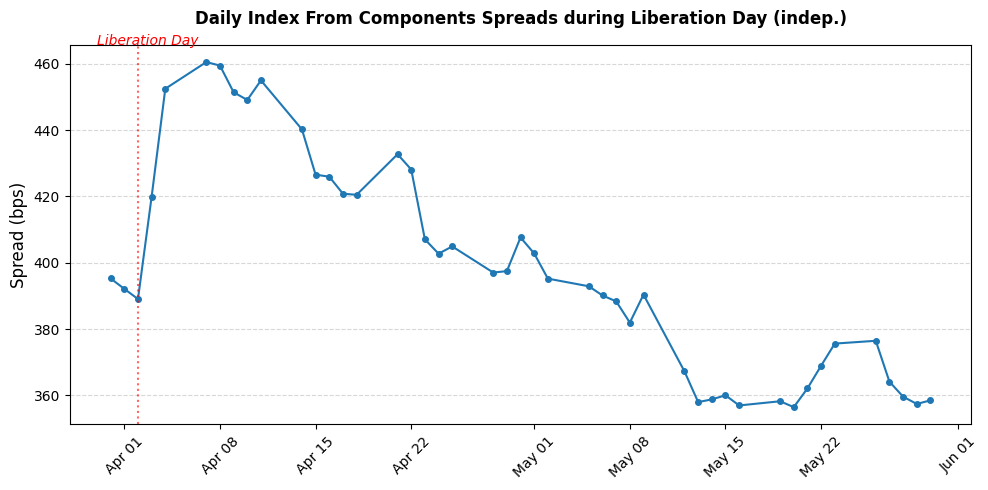

In [3]:
daily_index_spreads = []
for date, df_day in df:
    res = cds.index_from_component_spreads(df_day)
    daily_index_spreads.append({
        'date': date,
        'index_from_components': res['index_flat_calc_bp'],
    })

daily_index_spreads_df = pd.DataFrame(daily_index_spreads)

daily_index_spreads_df['date'] = pd.to_datetime(daily_index_spreads_df['date'])
plt.figure(figsize=(10, 5))
plt.plot(
    daily_index_spreads_df['date'], 
    daily_index_spreads_df['index_from_components'], 
    color='#1f77b4', 
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#1f77b4'
)
plt.title('Daily Index From Components Spreads during Liberation Day (indep.)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Spread (bps)', fontsize=12)
plt.xlabel('') 
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45) 
liberation_day = pd.to_datetime('2025-04-02')
plt.axvline(x=liberation_day, color='red', linestyle=':', alpha=0.6)
plt.text(
    liberation_day - pd.Timedelta(days=3),
    1, 
    'Liberation Day', 
    color='red', 
    fontsize=10, 
    style='italic',
    transform=plt.gca().get_xaxis_transform() 
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Ratings

In [4]:
rating_df = build_rating_df("CDX_HY_S44.json")

tot_flat = 0
for _, company in rating_df.iterrows():
    rating = company["RATING"]
    flat_spread = cds.flat_spread(rating) * 10000
    tot_flat += flat_spread

result = tot_flat / len(rating_df)
result

190.54954335557193

In [10]:
portfolio_df = build_portfolio_df(path_rating="CDX_HY_S44.json", path_spreads="fixed_us_spreads.json")
portfolio_df["Q_T"] = portfolio_df["RATING"].apply(lambda x: rating_to_pd(x, 5))
portfolio_df["w"] = 1.0
portfolio_df

,Company Name,RATING,Company,Date,cds_flat_spread,Q_T,w
0,American Airlines Group Inc,B+,American Airlines Group Inc,2025-03-31,688.270,0.17903,1.0
1,American Airlines Group Inc,B+,American Airlines Group Inc,2025-04-01,703.160,0.17903,1.0
2,American Airlines Group Inc,B+,American Airlines Group Inc,2025-04-02,701.365,0.17903,1.0
3,American Airlines Group Inc,B+,American Airlines Group Inc,2025-04-03,825.260,0.17903,1.0
4,American Airlines Group Inc,B+,American Airlines Group Inc,2025-04-04,909.400,0.17903,1.0
...,...,...,...,...,...,...,...
3777,Yum! Brands Inc,BB+,Yum! Brands Inc,2025-05-26,80.651,0.05682,1.0
3778,Yum! Brands Inc,BB+,Yum! Brands Inc,2025-05-27,82.243,0.05682,1.0
3779,Yum! Brands Inc,BB+,Yum! Brands Inc,2025-05-28,76.170,0.05682,1.0
3780,Yum! Brands Inc,BB+,Yum! Brands Inc,2025-05-29,75.339,0.05682,1.0


## Rating with index spreads

In [30]:
s_corr_medium = index_spread_with_correlation(portfolio_df, rho=0.5, alpha=0.05, T=5, r=0.02, recovery=0.4, freq=4)
s_corr_stress = index_spread_with_correlation(portfolio_df, rho=0.55, alpha=0.05, T=5, r=0.02, recovery=0.4, freq=4)
s_corr_very_stress = index_spread_with_correlation(portfolio_df, rho=0.6, alpha=0.05, T=5, r=0.02, recovery=0.4, freq=4)

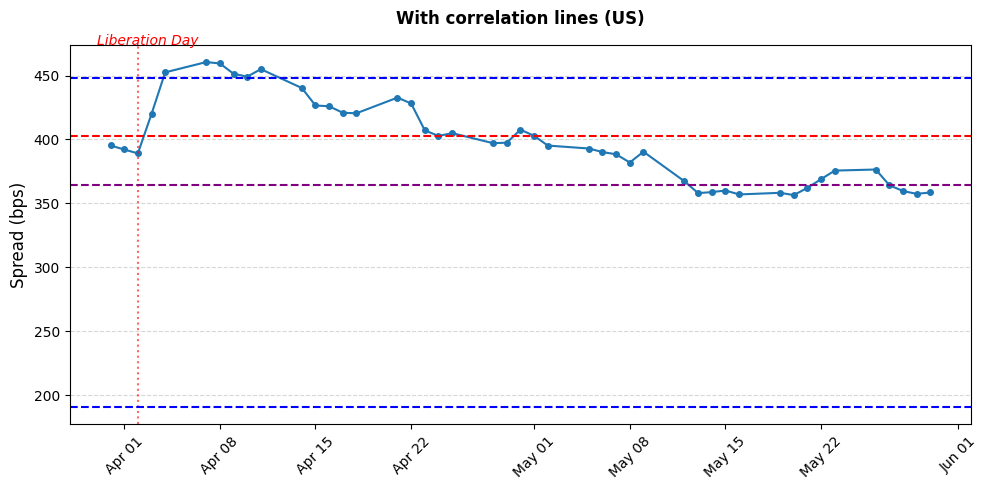

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(
    daily_index_spreads_df['date'], 
    daily_index_spreads_df['index_from_components'], 
    color='#1f77b4', 
    linewidth=1.5, 
    marker='o', 
    markersize=4,
    markerfacecolor='#1f77b4'
)
plt.title('With correlation lines (US)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Spread (bps)', fontsize=12)
plt.xlabel('') 
locator = mdates.AutoDateLocator(minticks=6, maxticks=12)
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45) 
liberation_day = pd.to_datetime('2025-04-02')
plt.axvline(x=liberation_day, color='red', linestyle=':', alpha=0.6)

plt.axhline(
     s_corr_stress,
     color="red",
     linestyle="--",
     label=f"Stressed"
 )
 
 #Medium
plt.axhline(
     s_corr_medium,
     color="purple",
     linestyle="--",
     label="Medium"
 )

 #Uncorrelated
plt.axhline(
     result,
     color="blue",
     linestyle="--",
     label="Rating-based spread"
 )


plt.axhline(
     s_corr_very_stress,
     color="blue",
     linestyle="--",
     label="Rating-based spread"
 )


plt.text(
    liberation_day - pd.Timedelta(days=3),
    1, 
    'Liberation Day', 
    color='red', 
    fontsize=10, 
    style='italic',
    transform=plt.gca().get_xaxis_transform() 
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Implied rho